In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV

In [8]:
DATA_DIR = "../data/splits/"
df = pd.read_parquet(DATA_DIR + "train_original.parquet")

In [9]:
print(df.shape)

(464710, 72)


Standarize data

In [10]:
X = df.drop('Cover_Type', axis=1).select_dtypes(include=[np.number])
y = df['Cover_Type']

# Feature Selection

In this section we will carry out the feature selection. We will follow different techniques such as, Variance Threshold, Recursive Feature Elimination, Lasso Regularization and Forward Selection. It is important to mention that regarding the dataset used, we will not be performing these stage of the process with any of the balance datasets. We are using the preprocessed dataset without imbalance mitigation. 

## PCA



In [11]:
pca = PCA()
pca.fit(X)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

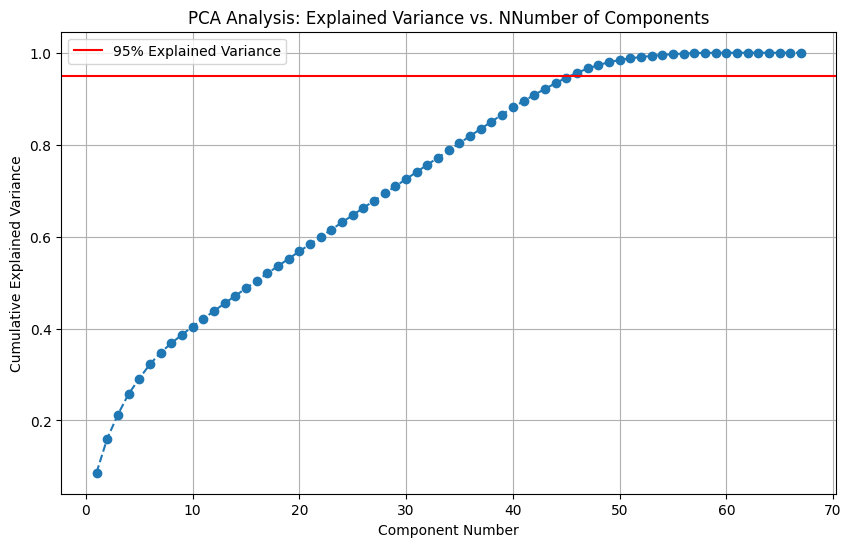

Number of components for 95% explained variance: 46


In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Component Number')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Analysis: Explained Variance vs. NNumber of Components')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components for 95% explained variance: {n_components_95}")

As we can see above, 46 components are needed to explain a 95% of variance. Originally, the dataset is formed by 69 features. This suggest that the dataset has an intrinsic high dimensionality and variables don't show high correlation among them.

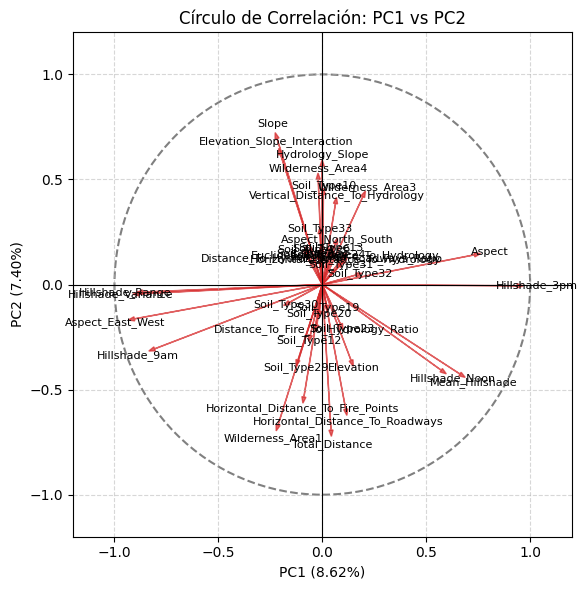

In [13]:
def plot_correlation_circle(pca, features, pc_x=0, pc_y=1, threshold=0.1):
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    xs = loadings[:, pc_x]
    ys = loadings[:, pc_y]
    
    plt.figure(figsize=(6, 6))
    
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.5)
    plt.gca().add_artist(circle)
    
    for i, feature in enumerate(features):
        magnitude = np.sqrt(xs[i]**2 + ys[i]**2)
        if magnitude > threshold:
            plt.arrow(0, 0, xs[i], ys[i], color='tab:red', head_width=0.02, alpha=0.7)
            plt.text(xs[i]*1.1, ys[i]*1.1, feature, color='black', ha='center', va='center', fontsize=8)
            
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.2f}%)")
    plt.ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.2f}%)")
    plt.title(f"Círculo de Correlación: PC{pc_x+1} vs PC{pc_y+1}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

# Llamar a la función
plot_correlation_circle(pca, X.columns)

## Variance Threshold

This technique simply consists of looking at the variance of the different features of the dataset. If the variance of a feature is close to zero, it means that it doesn't provide much information. This approach is computationally very cheap and it can reduce the dimensionality without any risk of overfitting, since it doesn't use the target.

In [14]:
p = 0.001 
th_val = p * (1 - p)

print(f"Calculated Variance Threshold: {th_val:.5f}")

sel = VarianceThreshold(threshold=th_val)

sel.fit(X)

irrelevant_cols = X.columns[~sel.get_support()]

print(f"Variables removed ({len(irrelevant_cols)}):")
print(list(irrelevant_cols))

X_var_filtered = X.loc[:, sel.get_support()]
X_var_filtered.head()

Calculated Variance Threshold: 0.00100
Variables removed (2):
['Wilderness_Count', 'Soil_Count']


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Distance_To_Hydrology_To_Roadways_Ratio,Distance_To_Fire_To_Hydrology_Ratio,Total_Distance,Hydrology_Slope,Mean_Hillshade,Hillshade_Variance,Hillshade_Range,Aspect_North_South,Aspect_East_West,Elevation_Slope_Interaction
0,0.551893,1.153850,-0.139758,0.175654,-0.192508,-0.474944,-1.088303,0.894536,1.358787,0.016526,...,1.184249,-0.183619,-0.254772,-0.291656,1.129863,-1.249667,-1.356861,0.121339,-1.695177,-0.047161
1,-0.494046,0.341045,0.628537,0.837801,-0.446862,-0.361235,-0.109795,1.828377,0.573896,-0.905968,...,1.278398,-0.196188,-0.741790,-0.808300,1.561597,-0.210508,-0.020158,-1.661407,-0.627846,0.577970
2,0.433316,-1.096993,1.062668,0.615909,0.256847,-0.667279,-0.279403,-1.673670,-1.024283,0.126077,...,1.310197,-0.187623,-0.237830,-0.023321,-1.639776,0.442180,0.514226,0.962374,0.531707,1.224307
3,-0.416785,-0.123414,-0.779115,-1.068070,-0.862279,-0.923532,0.774743,0.753948,-0.127794,0.313447,...,1.065789,-0.117563,-0.391345,-1.370926,0.735589,0.429977,0.329325,-1.397015,0.636408,-0.827088
4,0.868122,0.501820,-0.605606,-1.068070,-0.544466,0.569467,-0.153066,1.499301,0.739660,-0.557672,...,1.020121,-0.157273,0.040587,0.039498,1.602799,-0.530907,-0.350102,-1.484095,-1.052413,-0.497759


## RFECV (Recursive Feature Elimination with Cross Validation)

In this par of the featrure elimination process we are following the RFECV approach. This is a Recursive Feature Elimination approach with Cross Validation, which is more robust than the plain RFE. This approach tries with different feature subsets and selects the one that maximizes the score.

## Note:

It takes a lot to run, we missclicked once finished the run and in order to avoid the need of waiting again we stop it mid run

In [15]:
clf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
rfecv = RFECV(
    estimator=clf,
    step=2, 
    cv=StratifiedKFold(3), 
    scoring='f1_weighted', 
    min_features_to_select=10,
    n_jobs=-1
)

We are using as the scoring function the f1_weighted because, as we have mentioned before, we will carry out this process with the unbalanced dataset.

In [16]:
print("Executing RFECV...")
rfecv.fit(X_var_filtered, y)

Executing RFECV...


,estimator,RandomForestC...ndom_state=42)
,step,2
,min_features_to_select,10
,cv,StratifiedKFo...shuffle=False)
,scoring,'f1_weighted'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,50
,criterion,'gini'
,max_depth,8


In [17]:
print(f"Optimum number of features: {rfecv.n_features_}")
selected_features_rfecv = X_var_filtered.columns[rfecv.support_]
print("Selected Features:", list(selected_features_rfecv))

Optimum number of features: 27
Selected Features: ['Elevation', 'Aspect', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type2', 'Soil_Type4', 'Soil_Type10', 'Soil_Type12', 'Soil_Type22', 'Soil_Type23', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Euclidean_Distance_To_Hydrology', 'Distance_To_Hydrology_To_Roadways_Ratio', 'Distance_To_Fire_To_Hydrology_Ratio', 'Total_Distance', 'Hydrology_Slope', 'Aspect_North_South']


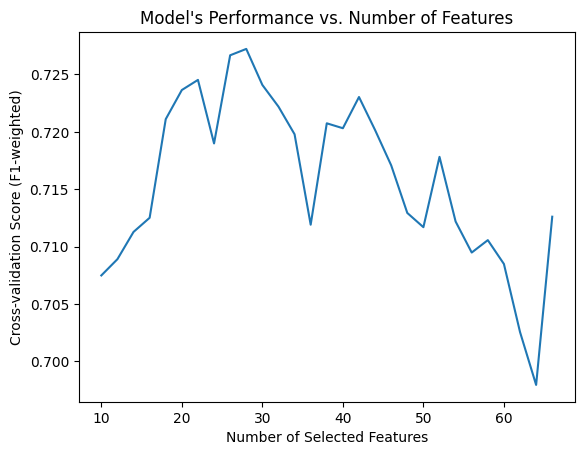

In [18]:
n_scores = len(rfecv.cv_results_["mean_test_score"])
plt.figure()
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-validation Score (F1-weighted)")
plt.plot(
    range(10, 10 + n_scores * 2, 2)[:n_scores],
    rfecv.cv_results_["mean_test_score"]
)
plt.title("Model's Performance vs. Number of Features")
plt.show()

We observe in the plot above, that the optimum number of features is 20. We see good performance also with 25 or 40 features, but the best score is achieved with the 20 features we have seen some cells above.

## Lasso Regularization

We will use a Logistic Regression with L1 penalty to perform feature selection. During the training, the model minimizes the loss as well as the magnitude of coefficients. This way, less important features obtain value 0 and thus, are removed and the model simplified. We will use Logistic Regression with Cross Validation to find the most optimal regularizer.

In [ ]:
print("Training Logistic Regression with L1 Penalty (Lasso)...")
lasso_lr = LogisticRegressionCV(
    solver='saga',           
    penalty='l1',            
    max_iter=1000,           
    cv=StratifiedKFold(3),                    
    scoring='f1_weighted',   
    n_jobs=-1,
    random_state=42,
    Cs=[0.001, 0.01, 0.1, 1],
    verbose=1
)

lasso_lr.fit(X_var_filtered, y)

print(f"\nBest parameter C found: {lasso_lr.C_[0]:.6f}")
print(f"Lambda (1/C): {1/lasso_lr.C_[0]:.6f}")

# Extract feature importance
# For multi-class problems, we get the maximum magnitude of coefficients
coefs = np.max(np.abs(lasso_lr.coef_), axis=0)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3005616381.py, line 10)

In [ ]:
lasso_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient_Magnitude': coefs,
    'Is_Selected': coefs > 0 
})

lasso_importance = lasso_importance.sort_values(by='Coefficient_Magnitude', ascending=False)

selected_features_lasso = lasso_importance[lasso_importance['Is_Selected']]['Feature'].tolist()

print(f"\n{'='*60}")
print(f"Number of features selected by Lasso: {len(selected_features_lasso)}")
print(f"Number of features removed: {len(X.columns) - len(selected_features_lasso)}")
print(f"{'='*60}")

print("\nTop 15 features by Lasso importance:")
lasso_importance.head(20)


Number of features selected by Lasso: 65
Number of features removed: 2

Top 15 features by Lasso importance:
                           Feature  Coefficient_Magnitude  Is_Selected
                         Elevation               6.850061         True
                    Total_Distance               3.328928         True
Horizontal_Distance_To_Fire_Points               2.123172         True
    Vertical_Distance_To_Hydrology               1.875579         True
   Horizontal_Distance_To_Roadways               1.869135         True
                  Wilderness_Area4               1.697328         True
                  Wilderness_Area1               1.603299         True
                    Mean_Hillshade               1.404774         True
                    Hillshade_Noon               1.044022         True
                Aspect_North_South               1.000837         True
       Elevation_Slope_Interaction               0.986377         True
                       Soil_Type29    

In [9]:
lasso_importance.to_csv("../data/interim/lasso_feature_importance.csv", index=False)

### Plot features

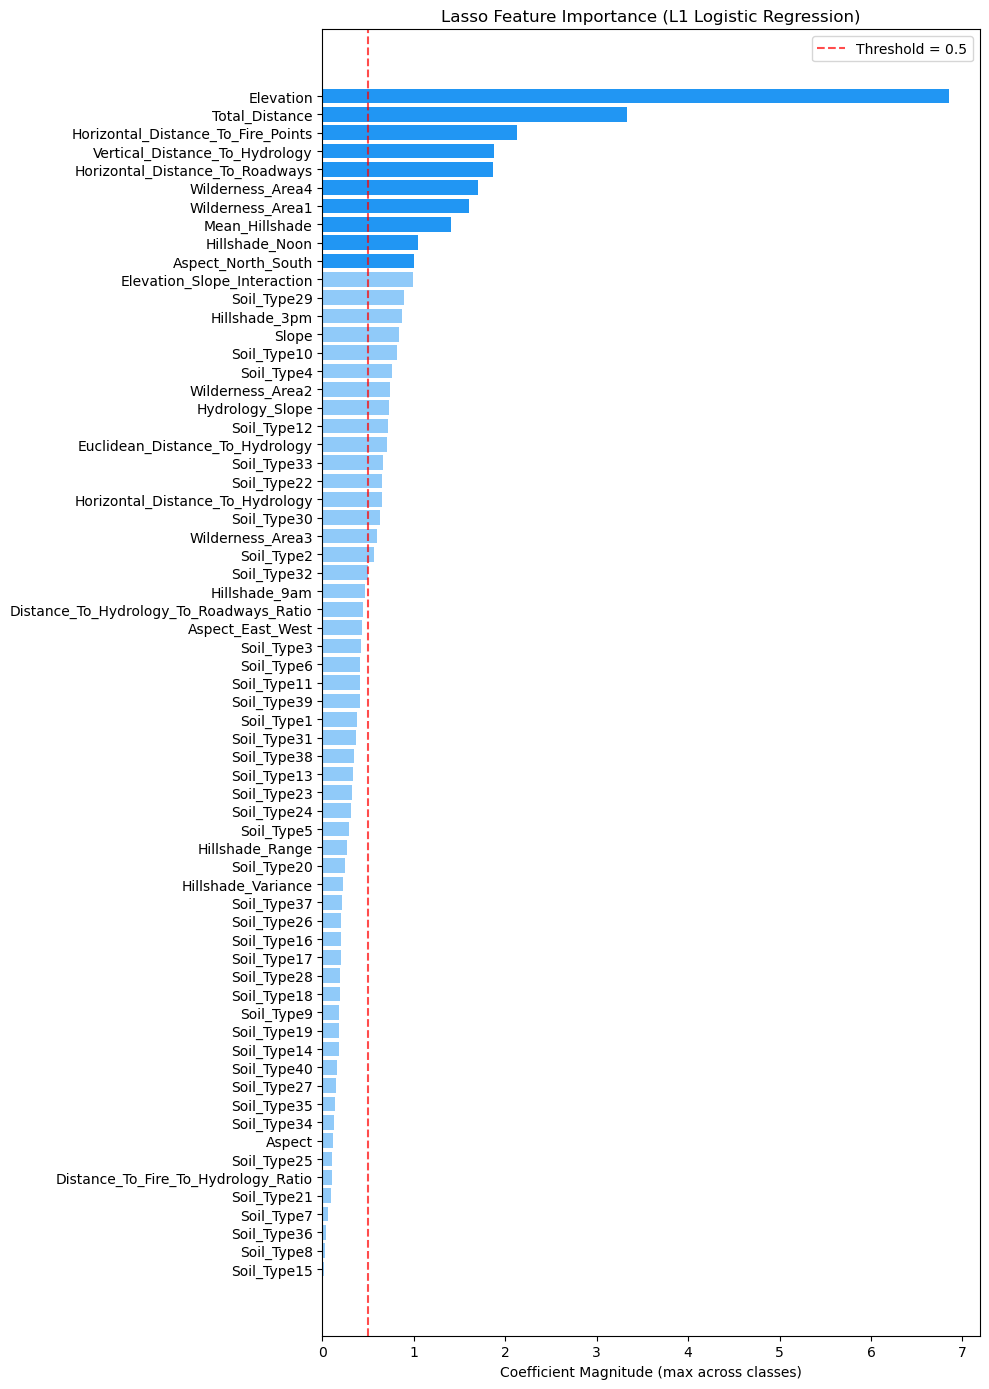

In [3]:
lasso_df = pd.read_csv("../data/interim/lasso_feature_importance.csv")
selected = lasso_df[lasso_df['Is_Selected']].sort_values('Coefficient_Magnitude', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#2196F3' if val >= 1.0 else '#90CAF9' for val in selected['Coefficient_Magnitude']]
ax.barh(selected['Feature'], selected['Coefficient_Magnitude'], color=colors)
ax.set_xlabel('Coefficient Magnitude (max across classes)')
ax.set_title('Lasso Feature Importance (L1 Logistic Regression)')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold = 0.5')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Then, filter only the columns that exist before dropping
variance_features = ['Soil_Type7', 'Soil_Type8', 'Soil_Type15', 
                    'Soil_Type25', 'Soil_Type36', 'Soil_Type37',
                    'Wilderness_Count', 'Soil_Count']

# Keep only features that exist in the dataframe
variance_features_to_drop = [col for col in variance_features if col in df.columns]

print(f"\nFeatures to drop: {variance_features_to_drop}")
print(f"Features not found: {set(variance_features) - set(variance_features_to_drop)}")

# Now drop only the existing columns
df_variance_t = df.drop(columns=variance_features_to_drop)
df_variance_t.to_parquet("../data/interim/df_variance_filtered.parquet")
# Also verify RFE and LASSO features exist
rfe_features = ['Elevation', 'Horizontal_Distance_To_Hydrology', 
                'Horizontal_Distance_To_Roadways', 'Hillshade_Noon', 
                'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
                'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type2', 
                'Soil_Type4', 'Soil_Type10', 'Soil_Type12', 'Soil_Type22', 'Soil_Type23', 'Soil_Type38',
                'Soil_Type39', 'Euclidean_Distance_To_Hydrology', 
                'Distance_To_Hydrology_To_Roadways_Ratio', 'Total_Distance', 'Aspect_North_South']

rfe_features_exist = [col for col in rfe_features if col in df.columns]
print(f"\nRFE features not found: {set(rfe_features) - set(rfe_features_exist)}")
df_rfe = df[rfe_features_exist]
df_rfe.to_parquet("../data/interim/df_rfe_filtered.parquet")

lasso_features = ['Elevation', 'Total_Distance', 'Horizontal_Distance_To_Fire_Points',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Wilderness_Area4', 'Wilderness_Area1', 'Mean_Hillshade',
                  'Hillshade_Noon', 'Aspect_North_South', 'Elevation_Slope_Interaction',
                  'Soil_Type29', 'Hillshade_3pm', 'Slope', 'Soil_Type10']

lasso_features_exist = [col for col in lasso_features if col in df.columns]
print(f"\nLASSO features not found: {set(lasso_features) - set(lasso_features_exist)}")
df_lasso = df[lasso_features_exist]
df_lasso.to_parquet("../data/interim/df_lasso_filtered.parquet")




Features to drop: ['Soil_Type7', 'Soil_Type8', 'Soil_Type15', 'Soil_Type25', 'Soil_Type36', 'Soil_Type37', 'Wilderness_Count', 'Soil_Count']
Features not found: set()

RFE features not found: set()

LASSO features not found: set()
